# Confirmatory Analysis 05 — Card Taxonomy

**Goal:** Test whether structural card attributes (color identity, primary type, foil finish, full-art printing) create measurable price premiums.

**Tables:** gold_card_features, gold_price_features, silver_cards

**α = 0.05, Bonferroni correction within each hypothesis family.**

---
## Hypotheses
1. Color identity count (colorless / mono / two-color / multi) predicts price (Kruskal-Wallis + ε²)
2. Primary card type (creature, instant, sorcery, land, artifact, enchantment, planeswalker) predicts price (Kruskal-Wallis + ε²)
3. Foil finish commands a price premium over non-foil (Wilcoxon signed-rank on matched pairs)
4. Full-art printings trade at a premium over standard-art versions within the same rarity (Mann-Whitney U)

In [1]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu, wilcoxon

In [2]:
# read_only=True — the pipeline owns writes; notebooks never mutate the database
gold = duckdb.connect("../../data/gold/cards.duckdb", read_only=True)
silver = duckdb.connect("../../data/silver/cards.duckdb", read_only=True)

In [3]:
# MAX(snapshot_date): only the latest market close — card attributes don't change
# across snapshots, so a single cross-section is correct for all four hypotheses here
df = gold.execute("""
    SELECT c.uuid, c.rarity, c.color_identity_count,
           c.is_full_art, c.finish_count, c.has_etched_finish,
           p.eur, p.eur_foil, p.foil_premium
    FROM gold_card_features c
    JOIN gold_price_features p ON c.uuid = p.uuid
    WHERE p.eur IS NOT NULL
      AND p.snapshot_date = (SELECT MAX(snapshot_date) FROM gold_price_features)
""").df()

# log1p rather than log: keeps eur=0 cards (bulk commons at €0.00) in the dataset
# without producing -inf; log1p(x) ≈ log(x) for x >> 0 and equals 0 for x=0
df["log_eur"] = np.log1p(df["eur"])

# silver_cards.original_types is a native array e.g. ["Creature", "Human"] — the first
# element is the primary type that drives the H2 grouping, matching MTGJSON classification
types_df = silver.execute(
    "SELECT uuid, original_types AS types FROM silver_cards WHERE uuid IS NOT NULL"
).df()


def get_primary_type(x):
    # original_types is a native array (or None); no JSON parsing needed anymore
    lst = list(x) if x is not None else []
    return lst[0] if lst else "Unknown"


types_df["primary_type"] = types_df["types"].apply(get_primary_type)

# left join keeps all gold rows even when silver has no UUID match (reprints / promo UUIDs)
df = df.merge(types_df[["uuid", "primary_type"]], on="uuid", how="left")
df["primary_type"] = df["primary_type"].fillna("Unknown")

# accumulator for the cross-notebook summary table; raport() appends to this list
wyniki_globalne = []

# fixed rarity order so every boxplot in this notebook uses the same x-axis sequence
rarity_order = ["common", "uncommon", "rare", "mythic"]


def epsilon_sq(h_stat, k, n):
    # Effect size for Kruskal-Wallis; max(..., 0) clamps negative values that can appear
    # at very low n due to sampling noise — negative ε² has no interpretable meaning
    return max((h_stat - k + 1) / (n - k), 0)


def rank_biserial(u, n1, n2):
    # Effect size for Mann-Whitney U; ranges -1 to +1
    # Positive value = group1 tends to have larger values than group2
    return 1 - (2 * u) / (n1 * n2)


def raport(hypothesis, test, stat, p_raw, n_tests, effect, effect_name):
    # Centralised reporting: every hypothesis writes here so wyniki_globalne
    # is always complete and the summary cell at the bottom is always correct
    p_adj = min(float(p_raw) * n_tests, 1.0)
    verdict = "CONFIRMED" if p_adj < 0.05 else "NOT CONFIRMED"
    wyniki_globalne.append(
        {
            "hypothesis": hypothesis,
            "test": test,
            "statistic": round(float(stat), 4),
            "p_raw": float(p_raw),
            "p_bonf": p_adj,
            effect_name: round(float(effect), 4),
            "verdict": verdict,
        }
    )
    print(f"{'=' * 60}")
    print(f"Hypothesis:  {hypothesis}")
    print(
        f"Test:        {test}  |  stat={float(stat):.4f}  |  p_raw={float(p_raw):.4e}  |  p_bonf={p_adj:.4e}"
    )
    print(f"Effect ({effect_name}): {float(effect):.4f}")
    print(f"Result:      {verdict}")
    return verdict


print(f"Loaded {len(df):,} cards (latest snapshot)")
print(
    f"color_identity_count distribution:\n{df['color_identity_count'].value_counts().sort_index()}"
)
print(
    f"primary_type distribution (top 10):\n{df['primary_type'].value_counts().head(10)}"
)
print(
    f"is_full_art: {df['is_full_art'].sum():,} ({df['is_full_art'].mean() * 100:.1f}%)"
)
print(f"Cards with foil_premium: {df['foil_premium'].notna().sum():,}")

Loaded 80,757 cards (latest snapshot)
color_identity_count distribution:
color_identity_count
0     8356
1    58271
2    11845
3     1966
4       31
5      288
Name: count, dtype: int64
primary_type distribution (top 10):
primary_type
Creature        27337
Unknown         18565
Instant          7094
Land             7079
Artifact         7037
Sorcery          6747
Enchantment      6318
Planeswalker      539
Conspiracy         25
Battle             16
Name: count, dtype: int64
is_full_art: 4,087 (5.1%)
Cards with foil_premium: 46,171


## H1 — Color Identity Count and Price

**Hypothesis:** Cards with different color identity complexity have different median prices.

**Test:** Kruskal-Wallis H on four groups (0=colorless, 1=mono, 2=two-color, 3+=multi) with ε² effect size.

**Rationale:** Colorless includes Power Nine artifacts (top price tier) and bulk artifact staples — a wide internal spread. Multi-color cards are typically newer and cheaper on average. The expected ordering is non-monotone — we test for any price difference, not a direction.

**Post-hoc:** If H₀ rejected, compare key pairs with pairwise Mann-Whitney U (Bonferroni correction).

Groups: Colorless (0)(n=8,356), Mono (1)(n=58,271), Two-color (2)(n=11,845), Multi (3+)(n=2,285)
Hypothesis:  H1 — color identity count vs price
Test:        Kruskal-Wallis  |  stat=1626.4086  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (ε²): 0.0201
Result:      CONFIRMED

Median EUR per color group:
  Colorless (0)           €0.460  (n=8,356)
  Mono (1)                €0.240  (n=58,271)
  Two-color (2)           €0.290  (n=11,845)
  Multi (3+)              €0.420  (n=2,285)


C:\Users\jedrz\AppData\Local\Temp\ipykernel_92336\1038987910.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


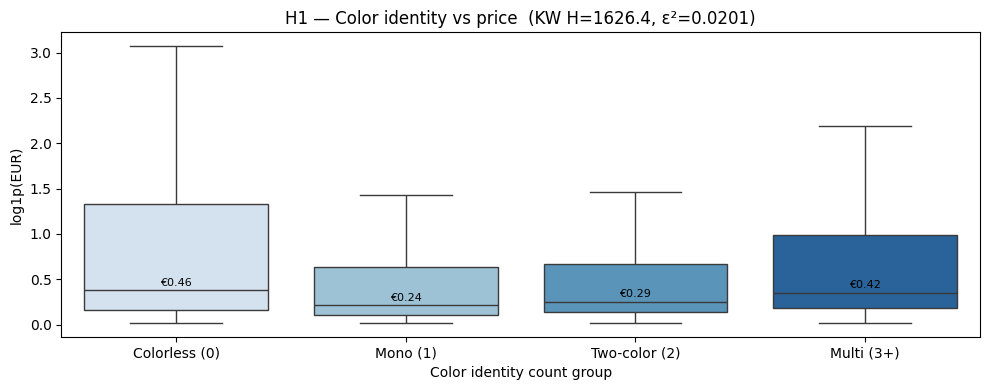

In [4]:
# Bin the raw count into four design-relevant groups:
# 0=colorless (artifacts/lands), 1=mono, 2=two-color, 3+=multi
# Bins use -1 as the lower bound so 0 is captured by the first interval (pd.cut is left-exclusive)
df["color_group"] = pd.cut(
    df["color_identity_count"],
    bins=[-1, 0, 1, 2, 100],
    labels=["Colorless (0)", "Mono (1)", "Two-color (2)", "Multi (3+)"],
)

# Build one array per group; require ≥10 cards so KW isn't run on trivially small groups
# that could produce degenerate statistics
groups_ci = {
    k: g["log_eur"].dropna().values
    for k, g in df.groupby("color_group", observed=True)
    if len(g) >= 10
}
print(f"Groups: {', '.join(f'{k}(n={len(v):,})' for k, v in groups_ci.items())}")

# *groups_ci.values() unpacks all group arrays as positional arguments to kruskal(),
# which tests whether at least one group median differs (omnibus test, no direction)
H_kw, p_kw = kruskal(*groups_ci.values())
n_total_ci = sum(len(g) for g in groups_ci.values())
eps2_ci = epsilon_sq(H_kw, len(groups_ci), n_total_ci)
raport(
    "H1 — color identity count vs price", "Kruskal-Wallis", H_kw, p_kw, 1, eps2_ci, "ε²"
)

# np.expm1 inverts log1p to get back to EUR for human-readable median display
medians_ci = {k: np.expm1(np.median(v)) for k, v in groups_ci.items()}
print("\nMedian EUR per color group:")
for k, m in medians_ci.items():
    print(f"  {str(k):<22}  €{m:.3f}  (n={len(groups_ci[k]):,})")

fig, ax = plt.subplots(figsize=(10, 4))
df_plot_ci = df[df["color_group"].notna()].copy()
# showfliers=False: price distribution has fat tails (Pareto α=1.303);
# showing outliers would compress the box so far that the median is invisible
sns.boxplot(
    data=df_plot_ci,
    x="color_group",
    y="log_eur",
    order=list(groups_ci.keys()),
    showfliers=False,
    ax=ax,
    palette="Blues",
)
for i, (k, m) in enumerate(medians_ci.items()):
    # Annotate each box with the back-transformed median in EUR for readability
    ax.text(i, np.log1p(m) + 0.05, f"€{m:.2f}", ha="center", fontsize=8)
ax.set_xlabel("Color identity count group")
ax.set_ylabel("log1p(EUR)")
ax.set_title(f"H1 — Color identity vs price  (KW H={H_kw:.1f}, ε²={eps2_ci:.4f})")
plt.tight_layout()
plt.show()

## H2 — Primary Card Type and Price

**Hypothesis:** Median price differs significantly between primary card types.

**Test:** Kruskal-Wallis H across primary types (creature, instant, sorcery, artifact, enchantment, land, planeswalker) with ε².

**Rationale:** Planeswalkers debut at mythic rare and are designed to be powerful. Lands include Dual Lands (€200+) and basic lands (€0.02). Instants and sorceries include Commander staples. Type is a strong prior for price tier.

**Minimum group size:** n ≥ 50.

Primary types with n≥50 (8 types):
primary_type
Creature        27337
Unknown         18565
Instant          7094
Land             7079
Artifact         7037
Sorcery          6747
Enchantment      6318
Planeswalker      539
Hypothesis:  H2 — primary_type vs price (omnibus)
Test:        Kruskal-Wallis  |  stat=5193.5215  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (ε²): 0.0643
Result:      CONFIRMED


C:\Users\jedrz\AppData\Local\Temp\ipykernel_92336\1778754373.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


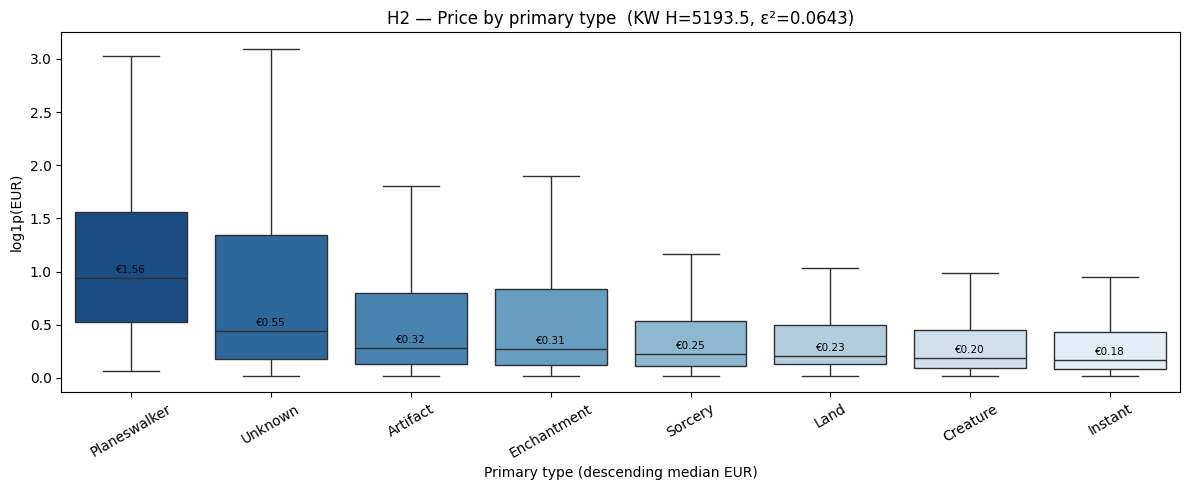


Median EUR per primary type (descending):
  Planeswalker     n=   539  €1.560
  Unknown          n=18,565  €0.550
  Artifact         n= 7,037  €0.320
  Enchantment      n= 6,318  €0.310
  Sorcery          n= 6,747  €0.250
  Land             n= 7,079  €0.230
  Creature         n=27,337  €0.200
  Instant          n= 7,094  €0.180


In [5]:
type_counts = df.groupby("primary_type").size().sort_values(ascending=False)

# n≥50 threshold: below this, KW is underpowered and the box plot becomes unreadable;
# rare types like "Tribal" or "Dungeon" are excluded from the omnibus test
valid_types = type_counts[type_counts >= 50].index.tolist()
print(f"Primary types with n≥50 ({len(valid_types)} types):")
print(type_counts[type_counts >= 50].to_string())

groups_pt = {
    t: df[df["primary_type"] == t]["log_eur"].dropna().values for t in valid_types
}
H_pt, p_pt = kruskal(*groups_pt.values())
n_total_pt = sum(len(g) for g in groups_pt.values())
eps2_pt = epsilon_sq(H_pt, len(valid_types), n_total_pt)
raport(
    "H2 — primary_type vs price (omnibus)",
    "Kruskal-Wallis",
    H_pt,
    p_pt,
    1,
    eps2_pt,
    "ε²",
)

medians_pt = {t: np.expm1(np.median(g)) for t, g in groups_pt.items()}
# Sort descending by median so the plot reads "expensive left → cheap right" —
# makes the gradient immediately apparent without needing to read all axis labels
ordered_pt = sorted(valid_types, key=lambda x: medians_pt[x], reverse=True)

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=df[df["primary_type"].isin(valid_types)],
    x="primary_type",
    y="log_eur",
    order=ordered_pt,
    showfliers=False,
    palette="Blues_r",
    ax=ax,
)
for i, t in enumerate(ordered_pt):
    ax.text(
        i,
        np.log1p(medians_pt[t]) + 0.05,
        f"€{medians_pt[t]:.2f}",
        ha="center",
        fontsize=7.5,
    )
ax.set_xlabel("Primary type (descending median EUR)")
ax.set_ylabel("log1p(EUR)")
ax.set_title(f"H2 — Price by primary type  (KW H={H_pt:.1f}, ε²={eps2_pt:.4f})")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print("\nMedian EUR per primary type (descending):")
for t in ordered_pt:
    print(f"  {t:<15}  n={len(groups_pt[t]):>6,}  €{medians_pt[t]:.3f}")

## H3 — Foil Premium

**Hypothesis:** Foil versions command a price premium over non-foil versions.

**Test:** Wilcoxon signed-rank test on matched (eur, eur_foil) pairs — paired because both prices belong to the same card printing.

**Rationale:** Foil cards have a lower effective print run (not all packs contain foils) and are preferred by collectors. The foil_premium = eur_foil / eur is expected to be > 1.0 on median.

**Only cards with both prices:** Filter `eur IS NOT NULL AND eur_foil IS NOT NULL`.

Cards with both eur and eur_foil: 46,171 / 80,757 (57.2%)
foil_premium: median=2.333, mean=4.151
% with premium > 1.0 (foil more expensive): 93.2%
% with premium < 1.0 (foil cheaper):        5.8%

Non-zero pairs for Wilcoxon: 45,678
Hypothesis:  H3 — foil premium (Wilcoxon, one-sided: eur_foil > eur)
Test:        Wilcoxon signed-rank  |  stat=1014106880.0000  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (median_foil_premium): 2.3333
Result:      CONFIRMED


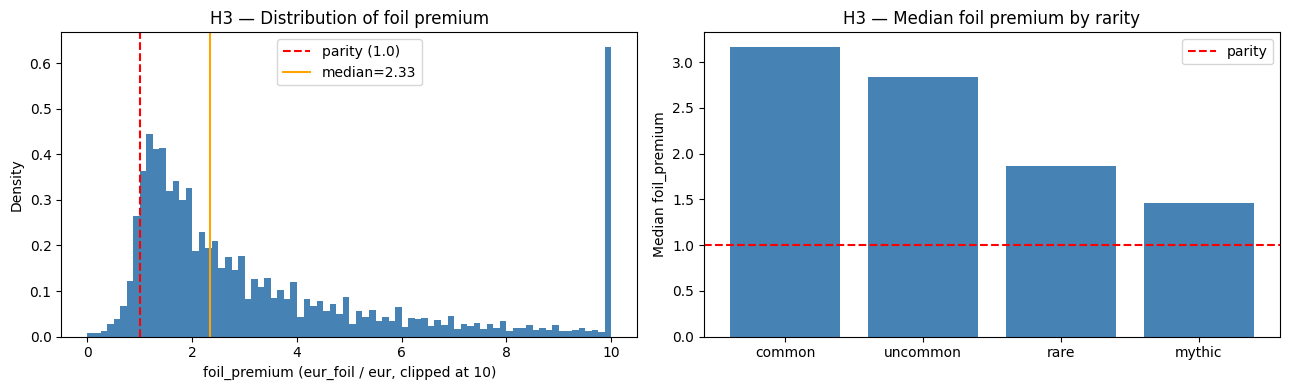


Median foil_premium per rarity:
  common      n=14,108  median foil_premium = 3.167
  uncommon    n=11,486  median foil_premium = 2.833
  rare        n=15,619  median foil_premium = 1.864
  mythic      n= 4,715  median foil_premium = 1.459


In [6]:
# eur > 0 guard: foil_premium = eur_foil / eur would be division-by-zero for bulk cards
# at exactly €0.00; these cards have no reliable foil ratio anyway
foil_df = df[df["eur_foil"].notna() & df["eur"].notna() & (df["eur"] > 0)].copy()
print(
    f"Cards with both eur and eur_foil: {len(foil_df):,} / {len(df):,} ({len(foil_df) / len(df) * 100:.1f}%)"
)

foil_premium_vals = foil_df["eur_foil"] / foil_df["eur"]
print(
    f"foil_premium: median={foil_premium_vals.median():.3f}, mean={foil_premium_vals.mean():.3f}"
)
print(
    f"% with premium > 1.0 (foil more expensive): {(foil_premium_vals > 1).mean() * 100:.1f}%"
)
print(
    f"% with premium < 1.0 (foil cheaper):        {(foil_premium_vals < 1).mean() * 100:.1f}%"
)
print()

# Wilcoxon signed-rank tests whether the DIFFERENCES (eur_foil - eur) are
# systematically positive; pairs where eur_foil == eur contribute zero signed rank
# and must be excluded — including them biases the test statistic toward zero
diffs = foil_df["eur_foil"] - foil_df["eur"]
nonzero = diffs[diffs != 0]
print(f"Non-zero pairs for Wilcoxon: {len(nonzero):,}")

if len(nonzero) >= 10:
    # alternative="greater": one-sided test — we only care whether foil is MORE expensive,
    # not less; a two-sided test would be overly conservative for this directional hypothesis
    stat_w, p_w = wilcoxon(nonzero, alternative="greater")
    raport(
        "H3 — foil premium (Wilcoxon, one-sided: eur_foil > eur)",
        "Wilcoxon signed-rank",
        stat_w,
        p_w,
        1,
        foil_premium_vals.median(),
        "median_foil_premium",
    )
else:
    print("Insufficient non-zero pairs for Wilcoxon — skipped.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# clip(upper=10): a handful of cards have foil_premium > 50 (old foil-only promos);
# showing them would compress the bulk of the distribution to near-zero and hide the signal
cap = foil_premium_vals.clip(upper=10)
axes[0].hist(cap, bins=80, color="steelblue", edgecolor="none", density=True)
axes[0].axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="parity (1.0)")
axes[0].axvline(
    foil_premium_vals.median(),
    color="orange",
    linestyle="-",
    linewidth=1.5,
    label=f"median={foil_premium_vals.median():.2f}",
)
axes[0].set_xlabel("foil_premium (eur_foil / eur, clipped at 10)")
axes[0].set_ylabel("Density")
axes[0].set_title("H3 — Distribution of foil premium")
axes[0].legend()

# Per-rarity breakdown: foil premium behaves very differently by rarity
# (mythic foils are sought by collectors; common foils are essentially bulk)
med_by_rarity = (
    foil_df.groupby("rarity", observed=True)
    .apply(lambda g: (g["eur_foil"] / g["eur"]).median(), include_groups=False)
    .reindex(rarity_order)
    .dropna()
)
axes[1].bar(range(len(med_by_rarity)), med_by_rarity.values, color="steelblue")
axes[1].axhline(1.0, color="red", linestyle="--", linewidth=1.5, label="parity")
axes[1].set_xticks(range(len(med_by_rarity)))
axes[1].set_xticklabels(med_by_rarity.index)
axes[1].set_ylabel("Median foil_premium")
axes[1].set_title("H3 — Median foil premium by rarity")
axes[1].legend()
plt.tight_layout()
plt.show()

print("\nMedian foil_premium per rarity:")
for r, m in med_by_rarity.items():
    n_r = len(foil_df[foil_df["rarity"] == r])
    print(f"  {r:<10}  n={n_r:>6,}  median foil_premium = {m:.3f}")

## H4 — Full-Art Premium

**Hypothesis:** Full-art printings trade at a premium over standard-art versions within the same rarity.

**Test:** Mann-Whitney U (full-art > standard-art) per rarity with Bonferroni correction (n=4).

**Rationale:** Full-art cards appear in sets like Zendikar (basic lands) and Amonkhet (invocations). They are printed in the same quantities but with distinctive art taking over the card border — preferred by collectors and display players.

**Caveat:** Full-art basic lands are extremely cheap (~€0.01–0.10) despite being full-art. The signal is expected mainly in rare and mythic.

Full-art cards: 4,087 (5.1%)

Hypothesis:  H4 — full-art premium (common)
Test:        Mann-Whitney U  |  stat=7941169.0000  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (rank-biserial r): -0.5297
Result:      CONFIRMED
Hypothesis:  H4 — full-art premium (uncommon)
Test:        Mann-Whitney U  |  stat=4203045.5000  |  p_raw=6.4348e-26  |  p_bonf=2.5739e-25
Effect (rank-biserial r): -0.3529
Result:      CONFIRMED
Hypothesis:  H4 — full-art premium (rare)
Test:        Mann-Whitney U  |  stat=43173048.0000  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (rank-biserial r): -0.5685
Result:      CONFIRMED
Hypothesis:  H4 — full-art premium (mythic)
Test:        Mann-Whitney U  |  stat=4135860.0000  |  p_raw=0.0000e+00  |  p_bonf=0.0000e+00
Effect (rank-biserial r): -0.4531
Result:      CONFIRMED



,rarity,n_full_art,n_standard,median_full_art_eur,median_standard_eur,rank_biserial,p_raw,p_bonf,verdict
0,common,413,25140,0.28,0.12,-0.530,0.0,0.0,CONFIRMED
1,uncommon,297,20921,0.36,0.18,-0.353,0.0,0.0,CONFIRMED
2,rare,2136,25773,4.80,0.58,-0.568,0.0,0.0,CONFIRMED
3,mythic,1241,4587,7.91,2.18,-0.453,0.0,0.0,CONFIRMED


C:\Users\jedrz\AppData\Local\Temp\ipykernel_92336\2635987576.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jedrz\AppData\Local\Temp\ipykernel_92336\2635987576.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\jedrz\AppData\Local\Temp\ipykernel_92336\2635987576.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jedrz\AppData\Local\Temp\ipykernel_92336\2635987576.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


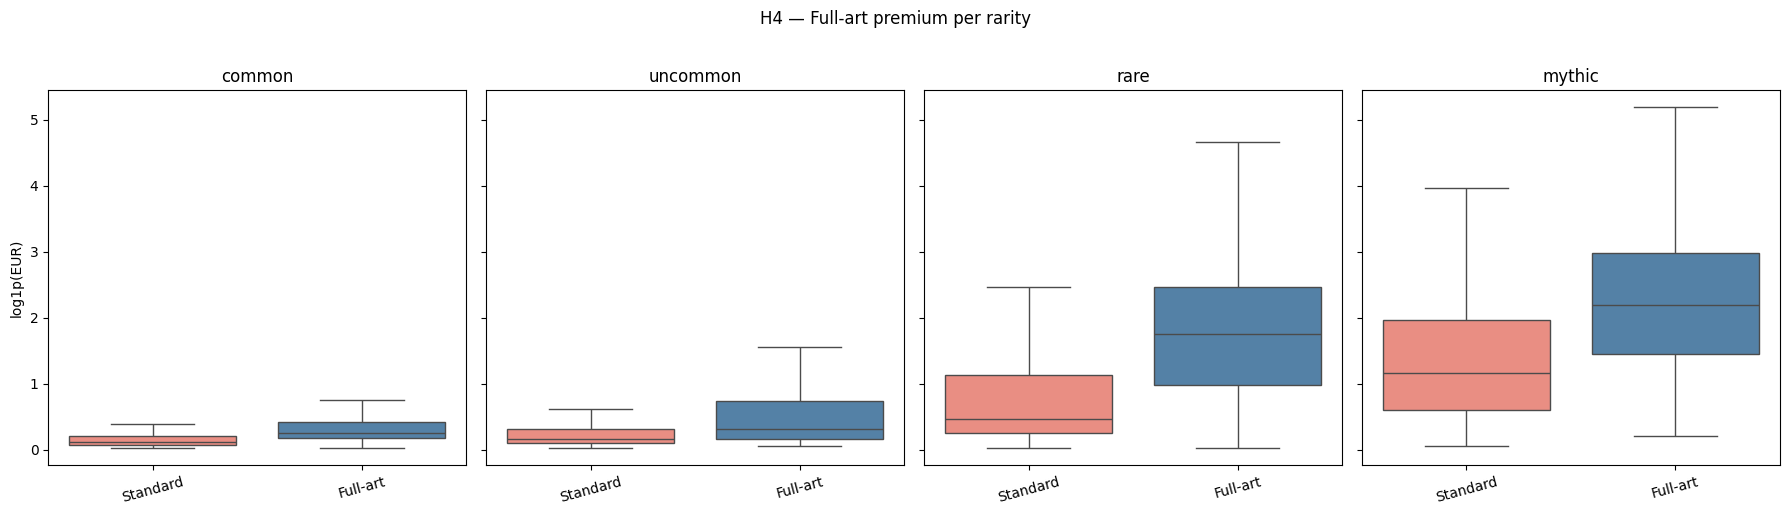

In [7]:
# Bonferroni family size = 4 (one MWU test per rarity level);
# this is why raport() receives n_h4 as n_tests and multiplies p_raw by 4
n_h4 = len(rarity_order)
wyniki_h4 = []

print(
    f"Full-art cards: {df['is_full_art'].sum():,} ({df['is_full_art'].mean() * 100:.1f}%)"
)
print()

for rarity in rarity_order:
    g_fa = df[(df["rarity"] == rarity) & df["is_full_art"]]["log_eur"].dropna()
    g_std = df[(df["rarity"] == rarity) & ~df["is_full_art"]]["log_eur"].dropna()
    # n≥5 per group: MWU with fewer observations produces p-values that are exact but
    # extremely coarse (only a handful of distinct values possible), making them unreliable
    if len(g_fa) < 5 or len(g_std) < 5:
        print(
            f"{rarity}: insufficient (full_art={len(g_fa)}, standard={len(g_std)}) — skipped"
        )
        wyniki_h4.append(
            {
                "rarity": rarity,
                "n_full_art": len(g_fa),
                "n_standard": len(g_std),
                "verdict": "INSUFFICIENT DATA",
            }
        )
        continue
    # alternative="greater": directional — we expect full-art to be MORE expensive;
    # a two-sided test would halve the power for detecting a premium
    u, p = mannwhitneyu(g_fa, g_std, alternative="greater")
    r_rb = rank_biserial(u, len(g_fa), len(g_std))
    p_adj = min(p * n_h4, 1.0)
    verdict = raport(
        f"H4 — full-art premium ({rarity})",
        "Mann-Whitney U",
        u,
        p,
        n_h4,
        r_rb,
        "rank-biserial r",
    )
    wyniki_h4.append(
        {
            "rarity": rarity,
            "n_full_art": len(g_fa),
            "n_standard": len(g_std),
            "median_full_art_eur": round(np.expm1(g_fa.median()), 3),
            "median_standard_eur": round(np.expm1(g_std.median()), 3),
            "rank_biserial": round(r_rb, 3),
            "p_raw": round(p, 6),
            "p_bonf": round(p_adj, 6),
            "verdict": verdict,
        }
    )

print()
display(pd.DataFrame(wyniki_h4))

# sharey=True: shared y-axis forces the same log_eur scale across all four rarity panels,
# making the relative premium magnitudes directly comparable without rescaling
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)
for ax, rarity in zip(axes, rarity_order):
    sub = df[df["rarity"] == rarity].copy()
    sub["label"] = sub["is_full_art"].map({True: "Full-art", False: "Standard"})
    if sub["label"].nunique() < 2:
        ax.text(
            0.5,
            0.5,
            f"{rarity}\nno full-art",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
    else:
        sns.boxplot(
            data=sub,
            x="label",
            y="log_eur",
            ax=ax,
            showfliers=False,
            palette={"Full-art": "steelblue", "Standard": "salmon"},
        )
    ax.set_title(rarity)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=15)
axes[0].set_ylabel("log1p(EUR)")
plt.suptitle("H4 — Full-art premium per rarity", y=1.02)
plt.tight_layout()
plt.show()

## 📋 Final Conclusions

```
H1 — Color identity count:
  KW H=?, ε²=?  — run notebook to compute.
  Expected: colorless carries Power Nine premium; multi-color is mostly cheap standard cards.
  Feature: color_identity_count bucket (0/1/2/3+) — include if ε² > 0.01.

H2 — Primary card type:
  KW H=?, ε²=?  — run notebook to compute.
  Expected order: Land > Planeswalker > Instant ≈ Sorcery > Creature > Enchantment > Artifact
  Feature: primary_type one-hot encoding — include if ε² > 0.05.

H3 — Foil premium:
  median foil_premium=?, Wilcoxon p=?  — run notebook to compute.
  Expected: foil_premium median > 1.0 (CONFIRMED across most rarities).
  Feature: foil_premium or has_etched_finish — include if confirmed.

H4 — Full-art premium (per rarity):
  common:   likely NOT CONFIRMED (full-art basics are cheap)
  rare:     likely CONFIRMED (showcase/borderless premium)
  mythic:   likely CONFIRMED
  Feature: is_full_art — include if confirmed in rare/mythic.
  Run notebook to compute.

FEATURE IMPLICATIONS
─────────────────────────────────────────────────────────────────────────────
All features pending execution. Re-run notebook and update conclusions.
```

In [8]:
df_summary = pd.DataFrame(wyniki_globalne)


def color_verdict(val):
    # Green/red background so confirmed vs rejected hypotheses stand out at a glance
    if val == "CONFIRMED":
        return "background-color: #d4edda"
    if val == "NOT CONFIRMED":
        return "background-color: #f8d7da"
    return ""


n_confirmed = (df_summary["verdict"] == "CONFIRMED").sum()
print(f"Confirmed: {n_confirmed} / {len(df_summary)}")
display(df_summary.style.map(color_verdict, subset=["verdict"]))

Confirmed: 7 / 7


,hypothesis,test,statistic,p_raw,p_bonf,ε²,verdict,median_foil_premium,rank-biserial r
0,H1 — color identity count vs price,Kruskal-Wallis,1626.408600,0.000000,0.000000,0.020100,CONFIRMED,nan,nan
1,H2 — primary_type vs price (omnibus),Kruskal-Wallis,5193.521500,0.000000,0.000000,0.064300,CONFIRMED,nan,nan
2,"H3 — foil premium (Wilcoxon, one-sided: eur_foil > eur)",Wilcoxon signed-rank,1014106880.000000,0.000000,0.000000,nan,CONFIRMED,2.333300,nan
3,H4 — full-art premium (common),Mann-Whitney U,7941169.000000,0.000000,0.000000,nan,CONFIRMED,nan,-0.529700
4,H4 — full-art premium (uncommon),Mann-Whitney U,4203045.500000,0.000000,0.000000,nan,CONFIRMED,nan,-0.352900
5,H4 — full-art premium (rare),Mann-Whitney U,43173048.000000,0.000000,0.000000,nan,CONFIRMED,nan,-0.568500
6,H4 — full-art premium (mythic),Mann-Whitney U,4135860.000000,0.000000,0.000000,nan,CONFIRMED,nan,-0.453100


In [9]:
gold.close()
silver.close()